# Statistical Arbitrage: Cointegration-Based Pairs Trading

This notebook implements an end-to-end, institutional-grade statistical arbitrage pairs trading pipeline using cointegration. The model uses the two-step Engle-Granger method to identify non-stationary asset pairs whose linear combination forms a stationary, mean-reverting spread. It split-tests historical data into **In-Sample** (parameter calibration, hedge ratio estimation, and half-life calculation) and **Out-of-Sample** (realistic forward backtesting) periods to avoid lookahead bias. The execution logic employs dynamic rolling Z-scores with transaction cost penalties to generate actionable long/short trading signals.

In [13]:
# Cell 2: Dependencies and Environment Setup

import sys
import subprocess

# Auto-install yfinance if missing in Colab environment
try:
    import yfinance as yf
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance", "-q"])
    import yfinance as yf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

# Configure plotting aesthetic
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✓ All libraries imported successfully.")

✓ All libraries imported successfully.


In [14]:
# Cell 2: Dependencies and Environment Setup

import sys
import subprocess

# Auto-install yfinance if missing in Colab environment
try:
    import yfinance as yf
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "yfinance", "-q"])
    import yfinance as yf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, coint

# Configure plotting aesthetic
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print("✓ All libraries imported successfully.")

✓ All libraries imported successfully.


In [15]:
# Cell 3: Data Acquisition & Train-Test Partitioning

def fetch_pair_data(ticker_a: str, ticker_b: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Downloads historical adjusted closing prices for a candidate asset pair.
    Handles missing values via forward/backward filling.
    """
    print(f"Fetching data for {ticker_a} and {ticker_b} from {start_date} to {end_date}...")
    try:
        data = yf.download([ticker_a, ticker_b], start=start_date, end=end_date, progress=False)['Close']
        # Handle MultiIndex if returned
        if isinstance(data.columns, pd.MultiIndex):
            data = data.droplevel(0, axis=1)
        data = data.ffill().bfill()

        if data.empty or data.shape[1] < 2:
            raise ValueError("Failed to retrieve adequate data for both tickers.")

        data = data[[ticker_a, ticker_b]].dropna()
        print(f"✓ Data retrieved successfully. Total rows: {len(data)}")
        return data
    except Exception as e:
        print(f"Error downloading data: {e}")
        raise

# Candidate Pair: EWA (Australia ETF) vs EWC (Canada ETF) - Classic Commodity Currency Arbitrage
TICKER_A = "EWA"
TICKER_B = "EWC"
START_DATE = "2018-01-01"
END_DATE = "2026-01-01"
SPLIT_DATE = "2022-12-31"

prices = fetch_pair_data(TICKER_A, TICKER_B, START_DATE, END_DATE)

# Partition into In-Sample (Calibration) and Out-of-Sample (Backtest)
train_prices = prices.loc[:SPLIT_DATE].copy()
test_prices = prices.loc[SPLIT_DATE:].copy()

print(f"In-Sample Period : {train_prices.index[0].strftime('%Y-%m-%d')} to {train_prices.index[-1].strftime('%Y-%m-%d')} ({len(train_prices)} bars)")
print(f"Out-of-Sample Period: {test_prices.index[0].strftime('%Y-%m-%d')} to {test_prices.index[-1].strftime('%Y-%m-%d')} ({len(test_prices)} bars)")

Fetching data for EWA and EWC from 2018-01-01 to 2026-01-01...
✓ Data retrieved successfully. Total rows: 2011
In-Sample Period : 2018-01-02 to 2022-12-30 (1259 bars)
Out-of-Sample Period: 2023-01-03 to 2025-12-31 (752 bars)


/tmp/ipykernel_1544/333553934.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download([ticker_a, ticker_b], start=start_date, end=end_date, progress=False)['Close']


In [16]:
# Cell 4: Statistical Testing & Cointegration Calibration (In-Sample)

def estimate_half_life(spread: pd.Series) -> float:
    """
    Calculates the half-life of mean reversion for a spread using an AR(1) process:
    dS_t = lambda * S_{t-1} + e_t
    Half-life = -ln(2) / lambda
    """
    spread_lag = spread.shift(1)
    spread_diff = spread - spread_lag
    spread_lag = spread_lag.dropna()
    spread_diff = spread_diff.dropna()

    # OLS regression of diff on lag
    model = sm.OLS(spread_diff, sm.add_constant(spread_lag)).fit()
    lambda_param = model.params.iloc[1]

    if lambda_param >= 0:
        return np.nan # Non-mean-reverting process

    half_life = -np.log(2) / lambda_param
    return float(half_life)

# 1. Engle-Granger Cointegration Test
score, p_value, _ = coint(train_prices[TICKER_A], train_prices[TICKER_B])

# 2. OLS Calibration to determine Hedge Ratio (Beta) and Intercept (Alpha)
X_train = sm.add_constant(train_prices[TICKER_B])
ols_model = sm.OLS(train_prices[TICKER_A], X_train).fit()

alpha = ols_model.params.iloc[0]
beta = ols_model.params.iloc[1]

# 3. Construct In-Sample Spread & Test Stationarity
train_spread = train_prices[TICKER_A] - (beta * train_prices[TICKER_B] + alpha)
adf_result = adfuller(train_spread)
half_life = estimate_half_life(train_spread)

# Statistical Output
print("=== IN-SAMPLE COINTEGRATION CALIBRATION ===")
print(f"Engle-Granger Test P-Value : {p_value:.4f} {'(Cointegrated at 5%)' if p_value < 0.05 else '(NOT Cointegrated)'}")
print(f"Hedge Ratio (Beta)          : {beta:.4f}")
print(f"Spread Intercept (Alpha)    : {alpha:.4f}")
print(f"ADF Statistic on Spread     : {adf_result[0]:.4f}")
print(f"ADF P-Value                 : {adf_result[1]:.4f}")
print(f"Spread Half-Life            : {half_life:.2f} trading days")

=== IN-SAMPLE COINTEGRATION CALIBRATION ===
Engle-Granger Test P-Value : 0.0876 (NOT Cointegrated)
Hedge Ratio (Beta)          : 0.4817
Spread Intercept (Alpha)    : 4.5478
ADF Statistic on Spread     : -3.1021
ADF P-Value                 : 0.0264
Spread Half-Life            : 32.38 trading days


In [17]:
# Cell 5: Out-of-Sample Spread Generation & Signal Engine

def generate_trading_signals(df: pd.DataFrame, ticker_a: str, ticker_b: str,
                             beta: float, alpha: float,
                             lookback_window: int = 60,
                             entry_z: float = 2.0,
                             exit_z: float = 0.0) -> pd.DataFrame:
    """
    Computes out-of-sample spread using fixed in-sample parameters, calculates rolling Z-scores,
    and executes long/short spread entry/exit logic without lookahead bias.
    """
    data = df.copy()

    # Calculate Spread using In-Sample parameters
    data['Spread'] = data[ticker_a] - (beta * data[ticker_b] + alpha)

    # Calculate Dynamic Rolling Mean and Standard Deviation
    data['Rolling_Mean'] = data['Spread'].rolling(window=lookback_window).mean()
    data['Rolling_Std'] = data['Spread'].rolling(window=lookback_window).std()

    # Rolling Z-score
    data['Z_Score'] = (data['Spread'] - data['Rolling_Mean']) / data['Rolling_Std']
    data = data.dropna().copy()

    # State-Based Signal Generation Algorithm
    # Position: +1 = Long Spread (Buy A, Sell B), -1 = Short Spread (Sell A, Buy B), 0 = Neutral
    positions = np.zeros(len(data))
    current_pos = 0

    z_scores = data['Z_Score'].values

    for i in range(len(data)):
        z = z_scores[i]

        if current_pos == 0:
            if z <= -entry_z:
                current_pos = 1  # Long the spread
            elif z >= entry_z:
                current_pos = -1 # Short the spread
        elif current_pos == 1:
            if z >= -exit_z:
                current_pos = 0  # Close long spread
        elif current_pos == -1:
            if z <= exit_z:
                current_pos = 0  # Close short spread

        positions[i] = current_pos

    data['Position'] = positions
    return data

LOOKBACK_WINDOW = int(round(half_life * 1.5)) if not np.isnan(half_life) else 45
ENTRY_Z = 2.0
EXIT_Z = 0.0

oos_strategy = generate_trading_signals(
    test_prices, TICKER_A, TICKER_B,
    beta, alpha,
    lookback_window=LOOKBACK_WINDOW,
    entry_z=ENTRY_Z, exit_z=EXIT_Z
)

print(f"✓ Out-of-sample signals generated. Lookback window set to {LOOKBACK_WINDOW} days.")

✓ Out-of-sample signals generated. Lookback window set to 49 days.


In [18]:
# Cell 6: Backtest Engine & Performance Metrics

def backtest_pairs_strategy(df: pd.DataFrame, ticker_a: str, ticker_b: str,
                             beta: float, transaction_cost_bps: float = 5.0) -> pd.DataFrame:
    """
    Evaluates strategy performance using daily returns, incorporating position shifts
    and proportional transaction costs.
    """
    bt = df.copy()
    cost_per_trade = transaction_cost_bps / 10000.0 # Bps to decimal

    # Asset daily simple returns
    bt['Ret_A'] = bt[ticker_a].pct_change().fillna(0)
    bt['Ret_B'] = bt[ticker_b].pct_change().fillna(0)

    # Spread return = Return of Long A - Beta * Return of B (weighted portfolio)
    # Total portfolio weight normalization = 1 + abs(beta)
    weight_norm = 1.0 + abs(beta)
    bt['Spread_Return'] = (bt['Ret_A'] - beta * bt['Ret_B']) / weight_norm

    # Strategy Return = Position_t-1 * Spread_Return_t
    bt['Raw_Strategy_Return'] = bt['Position'].shift(1).fillna(0) * bt['Spread_Return']

    # Detect position changes (trades) to deduct transaction cost
    bt['Trades'] = bt['Position'].diff().abs().fillna(0)
    bt['Transaction_Costs'] = bt['Trades'] * cost_per_trade

    # Net Strategy Return
    bt['Net_Strategy_Return'] = bt['Raw_Strategy_Return'] - bt['Transaction_Costs']

    # Cumulative Curves
    bt['Equity_Curve'] = (1 + bt['Net_Strategy_Return']).cumprod()

    # Benchmark 50/50 Buy & Hold Curve
    bt['Benchmark_Return'] = 0.5 * bt['Ret_A'] + 0.5 * bt['Ret_B']
    bt['Benchmark_Curve'] = (1 + bt['Benchmark_Return']).cumprod()

    return bt

def calculate_performance_summary(bt: pd.DataFrame) -> pd.Series:
    """Computes institutional performance metrics."""
    returns = bt['Net_Strategy_Return']
    trading_days = 252

    total_return = bt['Equity_Curve'].iloc[-1] - 1.0
    cagr = (bt['Equity_Curve'].iloc[-1]) ** (trading_days / len(bt)) - 1.0
    ann_vol = returns.std() * np.sqrt(trading_days)

    sharpe = (returns.mean() * trading_days) / (ann_vol + 1e-8)

    downside_returns = returns[returns < 0]
    downside_std = downside_returns.std() * np.sqrt(trading_days)
    sortino = (returns.mean() * trading_days) / (downside_std + 1e-8)

    # Drawdown Analysis
    peak = bt['Equity_Curve'].cummax()
    drawdown = (bt['Equity_Curve'] - peak) / peak
    max_drawdown = drawdown.min()

    # Win Rate
    traded_days = bt[bt['Position'].shift(1) != 0]
    win_rate = (traded_days['Net_Strategy_Return'] > 0).mean() if len(traded_days) > 0 else 0.0
    total_trades = int((bt['Trades'] > 0).sum())

    return pd.Series({
        "Total Return": f"{total_return * 100:.2f}%",
        "CAGR": f"{cagr * 100:.2f}%",
        "Annualized Volatility": f"{ann_vol * 100:.2f}%",
        "Sharpe Ratio": f"{sharpe:.2f}",
        "Sortino Ratio": f"{sortino:.2f}",
        "Max Drawdown": f"{max_drawdown * 100:.2f}%",
        "Win Rate (Active Days)": f"{win_rate * 100:.2f}%",
        "Total Trade Events": total_trades
    })

bt_results = backtest_pairs_strategy(oos_strategy, TICKER_A, TICKER_B, beta, transaction_cost_bps=5.0)
metrics = calculate_performance_summary(bt_results)

print("=== OUT-OF-SAMPLE PERFORMANCE SUMMARY ===")
print(metrics.to_string())

=== OUT-OF-SAMPLE PERFORMANCE SUMMARY ===
Total Return               7.60%
CAGR                       2.66%
Annualized Volatility      6.72%
Sharpe Ratio                0.42
Sortino Ratio               0.43
Max Drawdown              -7.90%
Win Rate (Active Days)    50.71%
Total Trade Events            31


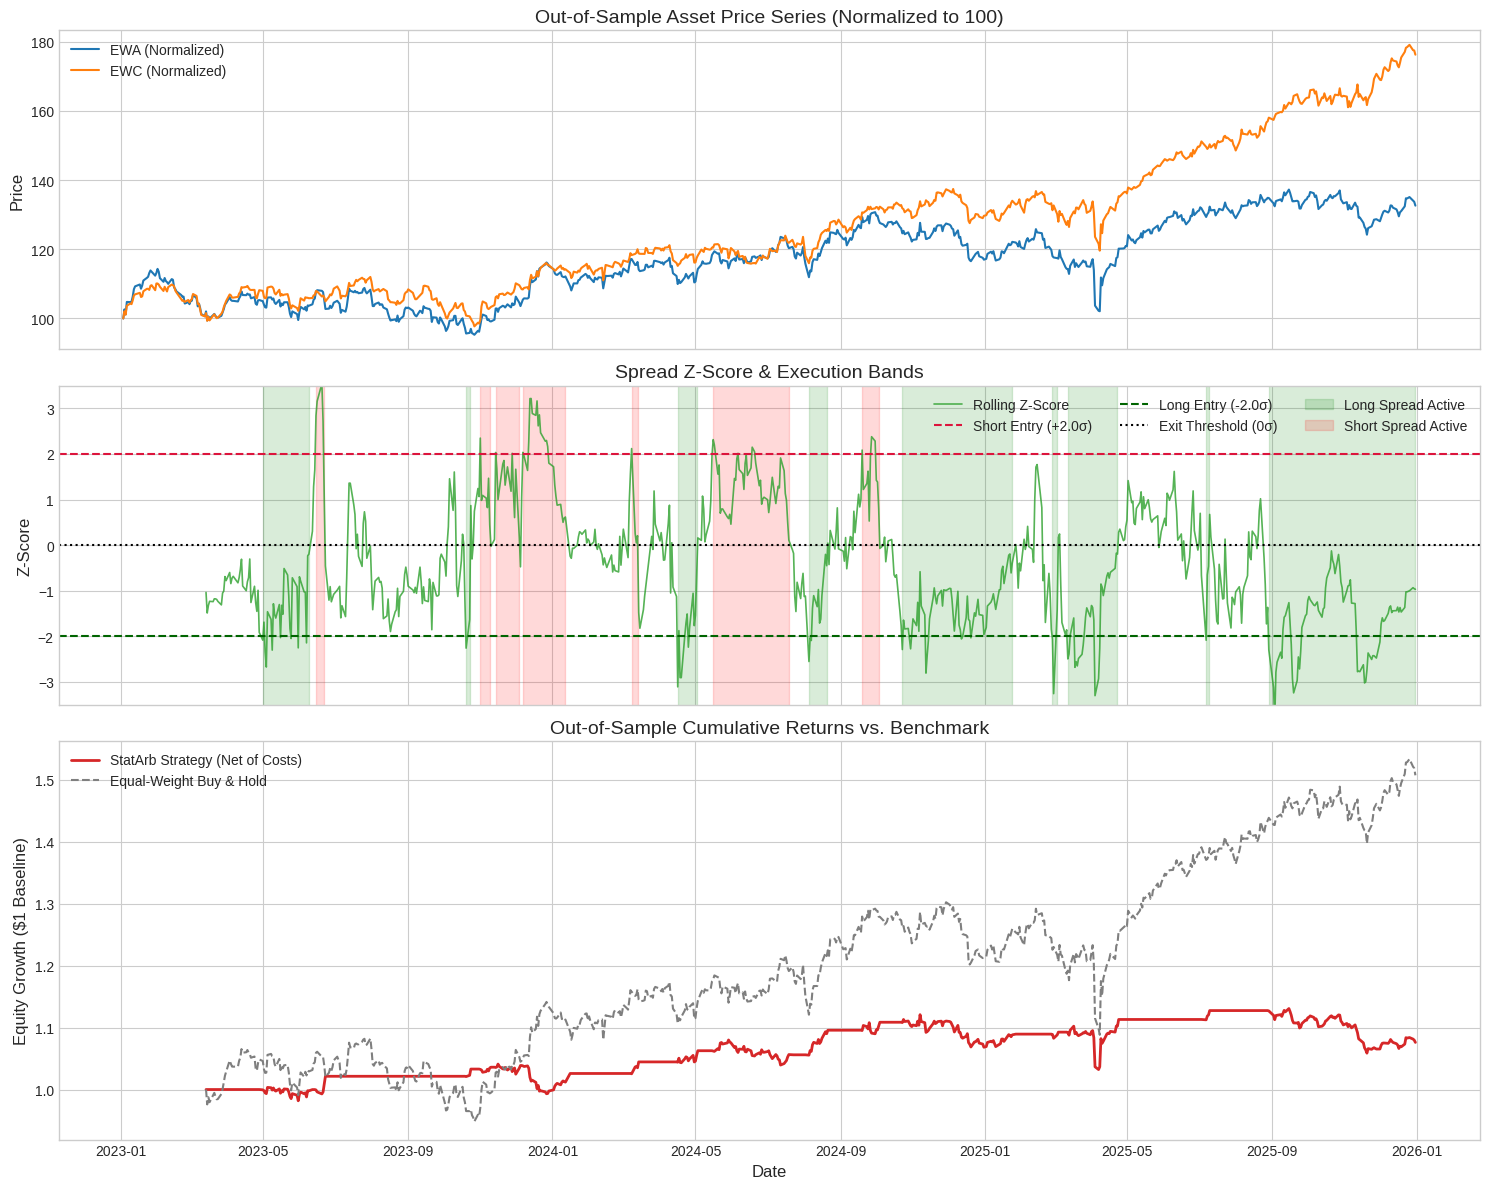

In [19]:
# Cell 7: Professional Visualizations Suite

fig, axes = plt.subplots(3, 1, figsize=(15, 12), sharex=True, gridspec_kw={'height_ratios': [1.2, 1.2, 1.5]})

# --- Panel 1: Normalized Out-of-Sample Prices ---
norm_prices = test_prices / test_prices.iloc[0] * 100
axes[0].plot(norm_prices.index, norm_prices[TICKER_A], label=f"{TICKER_A} (Normalized)", color='#1f77b4', lw=1.5)
axes[0].plot(norm_prices.index, norm_prices[TICKER_B], label=f"{TICKER_B} (Normalized)", color='#ff7f0e', lw=1.5)
axes[0].set_title("Out-of-Sample Asset Price Series (Normalized to 100)")
axes[0].set_ylabel("Price")
axes[0].legend(loc="upper left")

# --- Panel 2: Rolling Z-Score with Signal Overlays ---
axes[1].plot(bt_results.index, bt_results['Z_Score'], label="Rolling Z-Score", color='#2ca02c', alpha=0.8, lw=1.2)
axes[1].axhline(ENTRY_Z, color='crimson', linestyle='--', label=f'Short Entry (+{ENTRY_Z}σ)')
axes[1].axhline(-ENTRY_Z, color='darkgreen', linestyle='--', label=f'Long Entry (-{ENTRY_Z}σ)')
axes[1].axhline(EXIT_Z, color='black', linestyle=':', label='Exit Threshold (0σ)')

# Highlight active long and short positions
long_mask = bt_results['Position'] == 1
short_mask = bt_results['Position'] == -1
axes[1].fill_between(bt_results.index, -4, 4, where=long_mask, color='green', alpha=0.15, label='Long Spread Active')
axes[1].fill_between(bt_results.index, -4, 4, where=short_mask, color='red', alpha=0.15, label='Short Spread Active')

axes[1].set_ylim(-3.5, 3.5)
axes[1].set_title("Spread Z-Score & Execution Bands")
axes[1].set_ylabel("Z-Score")
axes[1].legend(loc="upper right", ncol=3)

# --- Panel 3: Cumulative Performance vs Benchmark ---
axes[2].plot(bt_results.index, bt_results['Equity_Curve'], label="StatArb Strategy (Net of Costs)", color='#d62728', lw=2)
axes[2].plot(bt_results.index, bt_results['Benchmark_Curve'], label="Equal-Weight Buy & Hold", color='#7f7f7f', linestyle='--', lw=1.5)
axes[2].set_title("Out-of-Sample Cumulative Returns vs. Benchmark")
axes[2].set_ylabel("Equity Growth ($1 Baseline)")
axes[2].set_xlabel("Date")
axes[2].legend(loc="upper left")

plt.tight_layout()
plt.show()